# Notebook 2: NumPy Fundamentals
### ML Skills Refresh Curriculum — Module 2 of 30

---
## 🎯 Learning Objectives

| # | Topic | Why It Matters in ML |
|---|-------|----------------------|
| 1 | What NumPy is & why it exists | Every ML library (Pandas, Scikit-learn, TensorFlow) sits on top of it |
| 2 | Creating 1-D, 2-D, and 3-D arrays | Features = 2-D arrays; image batches = 4-D arrays |
| 3 | Array attributes: `shape`, `size`, `dtype`, `ndim` | Debugging tensor mismatches is 90% reading shapes |
| 4 | Indexing & slicing | Selecting feature columns, extracting training windows |
| 5 | Element-wise array math | Feature scaling, residual computation, loss arithmetic |
| 6 | Aggregations & statistics | Computing mean, std, min, max across axes |

---

> **Dataset:** One week of weather data (temperature °C + rainfall mm) for **London, New York, and Tokyo**.
> This maps naturally onto 1-D, 2-D, and 3-D arrays in a single coherent story.

> **Scope:** Dot products, matrix multiplication, and broadcasting are intentionally excluded — those are Notebook 3.


---
## Section 1 — Why NumPy? The Speed Problem with Plain Python

### 📖 The Logic

A plain Python list stores **references** to objects scattered around memory. Python must check the type
of every element before doing arithmetic. For 10 million rows of training data this is catastrophically slow.

NumPy solves this with the **ndarray** (n-dimensional array):

| Property | Python list | NumPy ndarray |
|----------|-------------|---------------|
| Memory layout | Scattered pointers | One contiguous block |
| Element types | Mixed | Single, fixed `dtype` |
| Arithmetic | Python loop required | C-compiled, vectorised |
| Speed (10 M elements) | ~seconds | ~milliseconds |

**Rule of thumb:** if you are doing numeric computation in Python, use NumPy arrays, not lists.


In [ ]:
import numpy as np       # canonical alias used everywhere in data science
import time              # standard-library module for timing

N = 1_000_000            # one million elements

# ── Python list approach ──────────────────────────────────────────────────────
py_list = list(range(N))            # create a plain Python list 0..999999
start   = time.time()               # record start time
py_res  = [x * 2 for x in py_list] # double every element via list comprehension
py_time = time.time() - start       # elapsed seconds

# ── NumPy approach ────────────────────────────────────────────────────────────
np_arr  = np.arange(N)              # create NumPy array 0..999999
start   = time.time()               # record start time
np_res  = np_arr * 2                # double every element — NO explicit loop!
np_time = time.time() - start       # elapsed seconds

print(f'Python list time : {py_time*1000:.2f} ms')
print(f'NumPy array time : {np_time*1000:.2f} ms')
print(f'Speedup          : ~{py_time/max(np_time,1e-9):.0f}x faster with NumPy')


Python list time : 69.26 ms
NumPy array time : 6.43 ms
Speedup          : ~11x faster with NumPy


---
## Section 2 — Creating Arrays

### 📖 The Logic

Three common ways to get data into a NumPy array:
1. **`np.array()`** — convert an existing Python list (or list-of-lists).
2. **Constructor functions** — `np.zeros()`, `np.ones()`, `np.arange()`, `np.linspace()`.
3. **Random functions** — `np.random.rand()`, `np.random.randn()`, `np.random.randint()`.

### 2a — 1-D Arrays


In [ ]:
# ── Dataset: London daily temperatures (°C) Mon→Sun ─────────────────────────
london_temps = np.array([14, 15, 13, 16, 18, 20, 17])
#               np.array() converts a Python list → ndarray

print('london_temps :', london_temps)
print('type         :', type(london_temps))

# ── Other 1-D creation shortcuts ──────────────────────────────────────────────
zeros_arr    = np.zeros(7)          # array of 7 zeros — for initialising accumulators
ones_arr     = np.ones(7)           # array of 7 ones  — for mask operations
full_arr     = np.full(7, 99.0)     # array of 7 elements all set to 99.0
range_arr    = np.arange(0, 7)      # integers 0,1,2,3,4,5,6  (stop is exclusive)
linspace_arr = np.linspace(0,1,7)   # 7 evenly-spaced floats from 0.0 to 1.0

print('np.zeros(7)        :', zeros_arr)
print('np.ones(7)         :', ones_arr)
print('np.full(7,99)      :', full_arr)
print('np.arange(0,7)     :', range_arr)
print('np.linspace(0,1,7) :', np.round(linspace_arr, 4))


london_temps : [14 15 13 16 18 20 17]
type         : <class 'numpy.ndarray'>
np.zeros(7)        : [0. 0. 0. 0. 0. 0. 0.]
np.ones(7)         : [1. 1. 1. 1. 1. 1. 1.]
np.full(7,99)      : [99. 99. 99. 99. 99. 99. 99.]
np.arange(0,7)     : [0 1 2 3 4 5 6]
np.linspace(0,1,7) : [0.     0.1667 0.3333 0.5    0.6667 0.8333 1.    ]


### 2b — 2-D Arrays (Matrices)

A 2-D array has rows **and** columns — like a spreadsheet or feature matrix.
Standard ML convention: **rows = samples, columns = features**.

Here: **rows = cities, columns = days of the week.**


In [ ]:
# ── 2-D temperature array: 3 cities × 7 days ─────────────────────────────────
temp_matrix = np.array([
    [14, 15, 13, 16, 18, 20, 17],  # row 0 — London
    [22, 25, 24, 23, 26, 28, 27],  # row 1 — New York
    [18, 17, 19, 20, 21, 19, 18],  # row 2 — Tokyo
])  # shape → (3, 7)

city_names = ['London', 'New York', 'Tokyo']
day_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

print('Temperature matrix (°C):')
print(f'{"":>10}', ' '.join(f'{d:>5}' for d in day_labels))
for i, city in enumerate(city_names):
    row_str = ' '.join(f'{v:>5}' for v in temp_matrix[i])
    print(f'{city:>10}: {row_str}')

# ── 2-D constructor shortcuts ─────────────────────────────────────────────────
zeros_2d = np.zeros((3,7))   # 3 rows, 7 cols — all zeros
eye_3    = np.eye(3)         # 3×3 identity matrix
print('\nnp.eye(3):')
print(eye_3)


Temperature matrix (°C):
             Mon   Tue   Wed   Thu   Fri   Sat   Sun
    London:    14    15    13    16    18    20    17
  New York:    22    25    24    23    26    28    27
     Tokyo:    18    17    19    20    21    19    18

np.eye(3):
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


### 2c — 3-D Arrays (Tensors)

A 3-D array is a **stack of 2-D matrices**. We stack temperatures and rainfall
into one `(2, 3, 7)` tensor: **axis 0 = variable, axis 1 = city, axis 2 = day**.

In deep learning: `(batch_size, sequence_length, features)` is a classic 3-D shape.


In [ ]:
# ── Rainfall matrix: 3 cities × 7 days (mm/day) ──────────────────────────────
rain_matrix = np.array([
    [ 5,  0,  8,  2,  0,  0,  3],  # London
    [ 0,  0,  0,  1,  0,  0,  0],  # New York
    [10,  6, 12,  9,  4,  0,  7],  # Tokyo
])  # shape → (3, 7)

# np.array([m1, m2]) stacks two (3,7) matrices along a new axis 0 → shape (2,3,7)
weather_tensor = np.array([temp_matrix, rain_matrix])

print('weather_tensor shape:', weather_tensor.shape)   # (2, 3, 7)
print('\nSlice [0] — Temperature matrix:')
print(weather_tensor[0])   # first layer = temp_matrix
print('\nSlice [1] — Rainfall matrix:')
print(weather_tensor[1])   # second layer = rain_matrix


weather_tensor shape: (2, 3, 7)

Slice [0] — Temperature matrix:
[[14 15 13 16 18 20 17]
 [22 25 24 23 26 28 27]
 [18 17 19 20 21 19 18]]

Slice [1] — Rainfall matrix:
[[ 5  0  8  2  0  0  3]
 [ 0  0  0  1  0  0  0]
 [10  6 12  9  4  0  7]]


---
## Section 3 — Array Attributes

### 📖 The Logic

Every ndarray carries metadata baked in. Checking these is the **first thing you do**
when encountering an unfamiliar array — the NumPy equivalent of `df.info()`.

| Attribute | Returns | Meaning |
|-----------|---------|----------|
| `.ndim` | `int` | Number of axes |
| `.shape` | `tuple` | Size along each axis |
| `.size` | `int` | Total element count |
| `.dtype` | `dtype` | Data type of each element |
| `.itemsize` | `int` | Bytes per element |
| `.nbytes` | `int` | Total memory (`size × itemsize`) |


In [ ]:
def inspect(arr, name='array'):
    """Print a tidy attribute summary for any ndarray."""
    print(f'── {name} ──')
    print(f'  ndim     : {arr.ndim}')        # number of dimensions
    print(f'  shape    : {arr.shape}')       # tuple: size along each axis
    print(f'  size     : {arr.size}')        # total element count
    print(f'  dtype    : {arr.dtype}')       # element data type
    print(f'  itemsize : {arr.itemsize} B')  # bytes per element
    print(f'  nbytes   : {arr.nbytes} B')    # total memory footprint
    print()

inspect(london_temps,   'london_temps   (1-D)')
inspect(temp_matrix,    'temp_matrix    (2-D)')
inspect(weather_tensor, 'weather_tensor (3-D)')


── london_temps   (1-D) ──
  ndim     : 1
  shape    : (7,)
  size     : 7
  dtype    : int64
  itemsize : 8 B
  nbytes   : 56 B

── temp_matrix    (2-D) ──
  ndim     : 2
  shape    : (3, 7)
  size     : 21
  dtype    : int64
  itemsize : 8 B
  nbytes   : 168 B

── weather_tensor (3-D) ──
  ndim     : 3
  shape    : (2, 3, 7)
  size     : 42
  dtype    : int64
  itemsize : 8 B
  nbytes   : 336 B



### 3a — Data Types (`dtype`)

| dtype | Bits | Common use |
|-------|------|------------|
| `int32` | 32 | Integer labels, counts |
| `int64` | 64 | Large integer IDs (NumPy default int) |
| `float32` | 32 | **Deep learning default** — GPU-friendly |
| `float64` | 64 | NumPy default float — high precision |
| `bool` | 8 | Masks, flags |

> **ML tip:** TensorFlow/PyTorch default to `float32`; NumPy defaults to `float64`. Mismatches cause errors!


In [ ]:
# ── NumPy infers dtype from the values you provide ───────────────────────────
int_arr   = np.array([1, 2, 3])           # integers  → int64
float_arr = np.array([1.0, 2.0, 3.0])    # floats    → float64
bool_arr  = np.array([True, False, True]) # booleans  → bool

print('int_arr dtype  :', int_arr.dtype)
print('float_arr dtype:', float_arr.dtype)
print('bool_arr dtype :', bool_arr.dtype)

# ── Specify dtype explicitly ───────────────────────────────────────────────────
f32_arr = np.array([14, 15, 13], dtype=np.float32)  # force float32 for GPU work
print('\nf32_arr :', f32_arr, ' dtype:', f32_arr.dtype)

# ── Cast with .astype() — creates a NEW array ────────────────────────────────
f64 = int_arr.astype(np.float64)
print('f64     :', f64, ' dtype:', f64.dtype)

# ── Memory cost of float64 vs float32 ────────────────────────────────────────
big64 = np.zeros((1000,1000), dtype=np.float64)  # 1 M elements
big32 = np.zeros((1000,1000), dtype=np.float32)
print(f'\n1 M elements float64: {big64.nbytes/1024**2:.1f} MB')
print(f'1 M elements float32: {big32.nbytes/1024**2:.1f} MB  (half the memory!)')


int_arr dtype  : int64
float_arr dtype: float64
bool_arr dtype : bool

f32_arr : [14. 15. 13.]  dtype: float32
f64     : [1. 2. 3.]  dtype: float64

1 M elements float64: 7.6 MB
1 M elements float32: 3.8 MB  (half the memory!)


---
## Section 4 — Indexing & Slicing

### 📖 The Logic

General pattern for a 2-D array: `array[row_selector, column_selector]`

Each selector can be:
- A **single integer** → one element or a dimension is dropped
- A **`start:stop:step` slice** → sub-array
- A **list of indices** → fancy indexing (always a copy)
- A **boolean array** → mask indexing

> ⚠️ **Views vs copies:** Basic slicing returns a **view** (shared memory). Use `.copy()` when you need independence.


In [ ]:
# ── 1-D indexing ──────────────────────────────────────────────────────────────
print('london_temps       :', london_temps)
print('Index  0 (Mon)     :', london_temps[0])    # first element
print('Index -1 (Sun)     :', london_temps[-1])   # last element (negative index)
print('Slice [1:4] Tue-Thu:', london_temps[1:4])  # indices 1,2,3 (stop=4 excluded)
print('Slice [::2] alt    :', london_temps[::2])  # every other element
print('Slice [::-1] rev   :', london_temps[::-1]) # reversed
print('Slice [-3:]  Fri+  :', london_temps[-3:])  # last 3 elements


london_temps       : [14 15 13 16 18 20 17]
Index  0 (Mon)     : 14
Index -1 (Sun)     : 17
Slice [1:4] Tue-Thu: [15 13 16]
Slice [::2] alt    : [14 13 18 17]
Slice [::-1] rev   : [17 20 18 16 13 15 14]
Slice [-3:]  Fri+  : [18 20 17]


In [ ]:
# ── 2-D indexing ─────────────────────────────────────────────────────────────
print('temp_matrix:')
print(temp_matrix)
print()

print('[0,0] London Monday  :', temp_matrix[0, 0])   # row 0, col 0
print('[2,6] Tokyo Sunday   :', temp_matrix[2, 6])   # row 2, col 6
print('Row 1 (New York)     :', temp_matrix[1, :])   # all cols in row 1
print('Col 4 (Friday)       :', temp_matrix[:, 4])   # all rows in col 4
print('\nSub-matrix [0:2, 0:4]:')
print(temp_matrix[0:2, 0:4])                         # rows 0-1, cols 0-3


temp_matrix:
[[14 15 13 16 18 20 17]
 [22 25 24 23 26 28 27]
 [18 17 19 20 21 19 18]]

[0,0] London Monday  : 14
[2,6] Tokyo Sunday   : 18
Row 1 (New York)     : [22 25 24 23 26 28 27]
Col 4 (Friday)       : [18 26 21]

Sub-matrix [0:2, 0:4]:
[[14 15 13 16]
 [22 25 24 23]]


In [ ]:
# ── Fancy indexing — list of indices (always a COPY) ─────────────────────────
london_tokyo = temp_matrix[[0, 2], :]    # select rows 0 and 2; skip row 1
print('London & Tokyo:')
print(london_tokyo)

weekend = temp_matrix[:, [5, 6]]         # select columns 5 (Sat) and 6 (Sun)
print('\nWeekend temps (Sat, Sun):')
print(weekend)


London & Tokyo:
[[14 15 13 16 18 20 17]
 [18 17 19 20 21 19 18]]

Weekend temps (Sat, Sun):
[[20 17]
 [28 27]
 [19 18]]


In [ ]:
# ── Boolean (mask) indexing ───────────────────────────────────────────────────
mask     = london_temps > 15             # True where element > 15, else False
print('london_temps  :', london_temps)
print('mask (>15)    :', mask)

hot_days  = london_temps[mask]           # keeps only elements where mask is True
cold_days = london_temps[london_temps <= 14]  # one-liner shorthand
print('Hot days >15  :', hot_days)
print('Cold days <=14:', cold_days)

# ── ML analogy: filter predicted scores for the positive class ────────────────
labels = np.array([0, 1, 1, 0, 1, 0, 1])
scores = np.array([0.2, 0.8, 0.7, 0.3, 0.9, 0.4, 0.6])
pos_scores = scores[labels == 1]         # scores where label is 1
print('\nPositive-class scores:', pos_scores)


london_temps  : [14 15 13 16 18 20 17]
mask (>15)    : [False False False  True  True  True  True]
Hot days >15  : [16 18 20 17]
Cold days <=14: [14 13]

Positive-class scores: [0.8 0.7 0.9 0.6]


In [ ]:
# ── Views vs Copies — important gotcha ───────────────────────────────────────
original    = np.array([10, 20, 30, 40, 50])
view_slice  = original[1:4]             # slicing → VIEW (shared memory!)
view_slice[0] = 999                     # modify the view
print('view_slice:', view_slice)        # [999, 30, 40]
print('original  :', original)         # ← CHANGED: original[1] is now 999

# .copy() creates an independent array
original2  = np.array([10, 20, 30, 40, 50])
safe_copy  = original2[1:4].copy()     # .copy() breaks the shared-memory link
safe_copy[0] = 777
print('\nsafe_copy :', safe_copy)       # [777, 30, 40]
print('original2 :', original2)        # ← UNCHANGED


view_slice: [999  30  40]
original  : [ 10 999  30  40  50]

safe_copy : [777  30  40]
original2 : [10 20 30 40 50]


---
## Section 5 — Element-wise Array Math

### 📖 The Logic

NumPy operators (`+`, `-`, `*`, `/`, `**`) apply **element-by-element** on arrays of equal shape — no loop needed.

```
a = [1, 2, 3]    b = [10, 20, 30]
a + b  →  [11, 22, 33]    ← element-wise
a * 5  →  [ 5, 10, 15]    ← scalar
```

**ML uses:** zero-centering (`X - mean`), standardisation (`X / std`), residuals (`y_pred - y_true`), MSE (`(y_pred - y_true)**2`).


In [ ]:
# ── Scalar operations — same value applied to EVERY element ──────────────────
print('London temps (°C):', london_temps)

# Convert Celsius → Fahrenheit: F = C × 9/5 + 32
london_f   = london_temps * (9/5) + 32   # multiply each element by 1.8, add 32
print('London temps (°F):', np.round(london_f, 1))

# Calibration correction: add 0.5°C to every reading
calibrated = london_temps + 0.5          # add 0.5 to every element
print('Calibrated  (°C):', calibrated)

# Square every element
squared    = london_temps ** 2           # element-wise x²
print('Squared         :', squared)


London temps (°C): [14 15 13 16 18 20 17]
London temps (°F): [57.2 59.  55.4 60.8 64.4 68.  62.6]
Calibrated  (°C): [14.5 15.5 13.5 16.5 18.5 20.5 17.5]
Squared         : [196 225 169 256 324 400 289]


In [ ]:
# ── Array + Array — element-wise between two arrays of EQUAL shape ────────────
ny_temps    = temp_matrix[1]   # New York: [22,25,24,23,26,28,27]
tokyo_temps = temp_matrix[2]   # Tokyo:    [18,17,19,20,21,19,18]

print('New York temps :', ny_temps)
print('Tokyo temps    :', tokyo_temps)

# Average temp across NY and Tokyo for each day
avg = (ny_temps + tokyo_temps) / 2       # add element-wise, then divide by 2
print('\nDaily avg (NY+Tokyo)/2:', avg)

# Temperature difference
diff = ny_temps - tokyo_temps            # element-wise subtraction
print('NY minus Tokyo daily  :', diff)

# Element-wise multiplication (NOT a dot product)
weights    = np.array([1.0,0.8,1.2,1.0,0.9,1.1,1.0])  # day-of-week weights
weighted   = ny_temps * weights          # each day scaled by its weight
print('Weighted NY temps     :', np.round(weighted, 2))


New York temps : [22 25 24 23 26 28 27]
Tokyo temps    : [18 17 19 20 21 19 18]

Daily avg (NY+Tokyo)/2: [20.  21.  21.5 21.5 23.5 23.5 22.5]
NY minus Tokyo daily  : [4 8 5 3 5 9 9]
Weighted NY temps     : [22.  20.  28.8 23.  23.4 30.8 27. ]


In [ ]:
# ── Universal Functions (ufuncs) ──────────────────────────────────────────────
arr = np.array([1.0, 4.0, 9.0, 16.0, 25.0])
print('Original    :', arr)
print('np.sqrt()   :', np.sqrt(arr))       # square root of each element
print('np.log()    :', np.log(arr))        # natural log of each element
print('np.abs(-arr):', np.abs(arr - 10))   # absolute value of (arr - 10)

# ── ML use-case: Mean Squared Error computed from scratch ────────────────────
y_true = np.array([3.0, 5.0, 2.5, 7.0, 4.0])   # actual target values
y_pred = np.array([2.8, 5.3, 2.2, 6.5, 4.4])   # model predictions

residuals      = y_pred - y_true            # step 1: element-wise difference
squared_errors = residuals ** 2             # step 2: square each residual
mse            = squared_errors.mean()      # step 3: average all squared errors

print(f'\nResiduals      : {np.round(residuals,2)}')
print(f'Squared errors : {np.round(squared_errors,4)}')
print(f'MSE            : {mse:.4f}')
print(f'RMSE           : {np.sqrt(mse):.4f}')


Original    : [ 1.  4.  9. 16. 25.]
np.sqrt()   : [1. 2. 3. 4. 5.]
np.log()    : [0.         1.38629436 2.19722458 2.77258872 3.21887582]
np.abs(-arr): [ 9.  6.  1.  6. 15.]

Residuals      : [-0.2  0.3 -0.3 -0.5  0.4]
Squared errors : [0.04 0.09 0.09 0.25 0.16]
MSE            : 0.1260
RMSE           : 0.3550


---
## Section 6 — Aggregations & Statistics

### 📖 The Logic

Aggregation functions **collapse** a dimension into one summary value. The `axis` parameter controls which dimension:

```
Shape (3, 7):
  axis=None → one scalar (collapse everything)
  axis=0    → shape (7,)  — collapse ROWS    → one value per column
  axis=1    → shape (3,)  — collapse COLUMNS → one value per row
```

Memory trick: **axis=0 collapses rows**, **axis=1 collapses columns**.


In [ ]:
# ── Global aggregations ───────────────────────────────────────────────────────
print('temp_matrix:'); print(temp_matrix); print()
print(f'Global mean : {temp_matrix.mean():.2f} °C')
print(f'Global min  : {temp_matrix.min()} °C')
print(f'Global max  : {temp_matrix.max()} °C')
print(f'Global std  : {temp_matrix.std():.2f} °C')

# ── axis=1: collapse columns → one value PER ROW (per city) ──────────────────
city_means = temp_matrix.mean(axis=1)   # mean across 7 day-cols → shape (3,)
city_maxes = temp_matrix.max(axis=1)    # max  across 7 day-cols → shape (3,)
city_stds  = temp_matrix.std(axis=1)    # std  across 7 day-cols → shape (3,)

print('\nPer-city weekly stats:')
print(f'{"City":<12} {"Mean":>7} {"Max":>7} {"Std":>7}')
print('-'*35)
for i, city in enumerate(city_names):
    print(f'{city:<12} {city_means[i]:>7.1f} {city_maxes[i]:>7} {city_stds[i]:>7.2f}')

# ── axis=0: collapse rows → one value PER COLUMN (per day) ───────────────────
daily_means = temp_matrix.mean(axis=0)  # mean across 3 city-rows → shape (7,)
print('\nPer-day avg across all cities:')
for day, t in zip(day_labels, daily_means):
    print(f'  {day}: {t:.1f} °C')

warmest = np.argmax(daily_means)  # index of the highest daily mean
print(f'\nWarmest day on average: {day_labels[warmest]} ({daily_means[warmest]:.1f} °C)')


temp_matrix:
[[14 15 13 16 18 20 17]
 [22 25 24 23 26 28 27]
 [18 17 19 20 21 19 18]]

Global mean : 20.00 °C
Global min  : 13 °C
Global max  : 28 °C
Global std  : 4.15 °C

Per-city weekly stats:
City            Mean     Max     Std
-----------------------------------
London          16.1      20    2.23
New York        25.0      28    2.00
Tokyo           18.9      21    1.25

Per-day avg across all cities:
  Mon: 18.0 °C
  Tue: 19.0 °C
  Wed: 18.7 °C
  Thu: 19.7 °C
  Fri: 21.7 °C
  Sat: 22.3 °C
  Sun: 20.7 °C

Warmest day on average: Sat (22.3 °C)


In [ ]:
# ── Other commonly-used NumPy functions ───────────────────────────────────────
print('london_temps original :', london_temps)
print('np.sort()             :', np.sort(london_temps))      # ascending sort

# argsort() returns INDICES that would sort the array — useful for ranking
rank_idx = np.argsort(london_temps)     # positions of values in ascending order
print('argsort indices       :', rank_idx)
print('Days coldest→hottest  :', [day_labels[i] for i in rank_idx])

# argmax / argmin — index of the extremes
hottest = np.argmax(london_temps)
coldest = np.argmin(london_temps)
print(f'\nHottest: {day_labels[hottest]} ({london_temps[hottest]} °C)')
print(f'Coldest: {day_labels[coldest]} ({london_temps[coldest]} °C)')

# cumsum() — running total (useful for cumulative rainfall, reward in RL)
london_rain    = rain_matrix[0]
cumulative_rain = np.cumsum(london_rain)
print('\nLondon daily rain (mm):', london_rain)
print('Cumulative rain (mm)  :', cumulative_rain)


london_temps original : [14 15 13 16 18 20 17]
np.sort()             : [13 14 15 16 17 18 20]
argsort indices       : [2 0 1 3 6 4 5]
Days coldest→hottest  : ['Wed', 'Mon', 'Tue', 'Thu', 'Sun', 'Fri', 'Sat']

Hottest: Sat (20 °C)
Coldest: Wed (13 °C)

London daily rain (mm): [5 0 8 2 0 0 3]
Cumulative rain (mm)  : [ 5  5 13 15 15 15 18]


---
## Section 7 — Reshaping Arrays

### 📖 The Logic

Reshaping changes the **shape** without changing the data — total elements must stay the same.

**ML uses:** flattening image pixels for a dense layer, adding a batch dimension, converting predictions to a grid.


In [ ]:
flat     = np.arange(1, 22)             # 1-D: [1..21], 21 elements
print('flat shape       :', flat.shape) # (21,)

grid     = flat.reshape(3, 7)           # 3 rows × 7 cols (3×7=21 ✓)
print('reshape(3,7)     :', grid.shape)
print(grid)

# -1 as a wildcard: NumPy infers that dimension automatically
grid_auto = flat.reshape(3, -1)         # 3 rows, NumPy infers cols = 7
print('\nreshape(3,-1) shape:', grid_auto.shape)

# flatten() — always returns a COPY
flat_copy = grid.flatten()              # (3,7) → (21,) copy
print('flatten() shape  :', flat_copy.shape)

# ravel() — returns a VIEW when possible (faster than flatten)
ravelled  = grid.ravel()               # (3,7) → (21,) view
print('ravel()   shape  :', ravelled.shape)

# Practical: flatten our temp_matrix into a 1-D feature vector
fv = temp_matrix.flatten()             # (3,7) → (21,)
print('\ntemp_matrix as feature vector:', fv)


flat shape       : (21,)
reshape(3,7)     : (3, 7)
[[ 1  2  3  4  5  6  7]
 [ 8  9 10 11 12 13 14]
 [15 16 17 18 19 20 21]]

reshape(3,-1) shape: (3, 7)
flatten() shape  : (21,)
ravel()   shape  : (21,)

temp_matrix as feature vector: [14 15 13 16 18 20 17 22 25 24 23 26 28 27 18 17 19 20 21 19 18]


---
## Section 8 — Random Number Generation

### 📖 The Logic

Random arrays are used for weight initialisation, train/test splits, data augmentation, and synthetic testing.
Always set a **random seed** so results are **reproducible**.


In [ ]:
np.random.seed(42)   # any integer — same seed → same sequence every time

# rand() — uniform [0, 1)
print('rand(5)    :', np.round(np.random.rand(5), 4))

# randn() — standard normal (mean=0, std=1) — used in neural network weight init
print('randn(3,4):')
print(np.round(np.random.randn(3, 4), 3))

# randint(low, high, size) — random integers in [low, high)
rand_labels = np.random.randint(0, 3, size=10)  # 10 random labels: 0, 1, or 2
print('\nrandom labels:', rand_labels)

# choice() — sample from an existing array
idx_pool = np.arange(5)
sampled  = np.random.choice(idx_pool, size=3, replace=False)  # 3 unique picks
print('sampled idx  :', sampled)

# shuffle() — shuffle IN PLACE (modifies the array; no return value)
arr_sh = np.arange(7)
np.random.shuffle(arr_sh)
print('shuffled 0-6 :', arr_sh)


rand(5)    : [0.3745 0.9507 0.732  0.5987 0.156 ]
randn(3,4):
[[ 0.279  1.011 -0.581 -0.525]
 [-0.571 -0.924 -2.613  0.95 ]
 [ 0.816 -1.524 -0.428 -0.742]]

random labels: [2 1 1 2 1 2 2 0 2 0]
sampled idx  : [1 3 0]
shuffled 0-6 : [4 2 5 0 3 1 6]


---
## Section 9 — Visualisation

### 📖 What We Are Plotting

1. **Line chart** — Weekly temperatures for all 3 cities (rows of `temp_matrix`).
2. **Bar chart** — Per-city weekly mean (result of `axis=1` aggregation).
3. **Heatmap** — The full `temp_matrix` as a colour grid — the natural way to inspect a 2-D array.


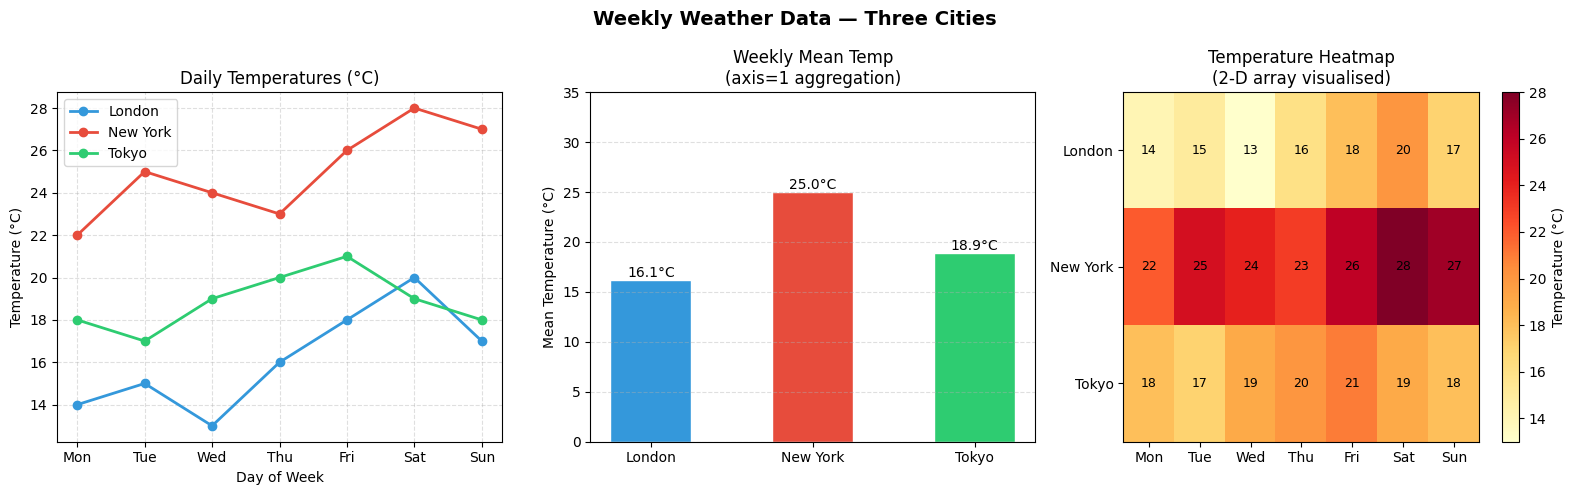


📊 Reading the charts:
  Left   — Each line is one ROW of temp_matrix. New York is warmest throughout.
  Middle — Each bar is the axis=1 mean — collapses 7 columns into one summary.
  Right  — Heatmap: darker red = higher temp. Spot the hot NY weekend at a glance.



In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))  # 1 row, 3 subplots
fig.suptitle('Weekly Weather Data — Three Cities', fontsize=14, fontweight='bold')

colors = ['#3498db', '#e74c3c', '#2ecc71']   # blue=London, red=NY, green=Tokyo
x_days = np.arange(7)                        # x positions 0..6

# ════ Plot 1: Line chart — all cities ════
ax1 = axes[0]
for i, city in enumerate(city_names):
    ax1.plot(x_days, temp_matrix[i],          # row i of temp_matrix
             marker='o', color=colors[i], linewidth=2, label=city)
ax1.set_title('Daily Temperatures (°C)')
ax1.set_xlabel('Day of Week')
ax1.set_ylabel('Temperature (°C)')
ax1.set_xticks(x_days)
ax1.set_xticklabels(day_labels)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.4)

# ════ Plot 2: Bar chart — per-city mean ════
ax2 = axes[1]
city_means = temp_matrix.mean(axis=1)         # axis=1 → one mean per city
bars = ax2.bar(city_names, city_means, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, city_means):        # annotate each bar
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}°C', ha='center', fontsize=10)
ax2.set_title('Weekly Mean Temp\n(axis=1 aggregation)')
ax2.set_ylabel('Mean Temperature (°C)')
ax2.set_ylim(0, 35)
ax2.grid(axis='y', linestyle='--', alpha=0.4)

# ════ Plot 3: Heatmap — raw 2-D array as colour ════
ax3 = axes[2]
im  = ax3.imshow(temp_matrix, cmap='YlOrRd', aspect='auto')  # colour-encode values
plt.colorbar(im, ax=ax3, label='Temperature (°C)')
ax3.set_xticks(x_days)
ax3.set_xticklabels(day_labels)
ax3.set_yticks(range(3))
ax3.set_yticklabels(city_names)
for row in range(3):                          # annotate each cell
    for col in range(7):
        ax3.text(col, row, str(temp_matrix[row, col]),
                 ha='center', va='center', fontsize=9)
ax3.set_title('Temperature Heatmap\n(2-D array visualised)')

plt.tight_layout()
plt.show()

print("""
📊 Reading the charts:
  Left   — Each line is one ROW of temp_matrix. New York is warmest throughout.
  Middle — Each bar is the axis=1 mean — collapses 7 columns into one summary.
  Right  — Heatmap: darker red = higher temp. Spot the hot NY weekend at a glance.
""")


---
## ✅ Notebook Summary & Cheat-sheet

```python
# ── Creation ──────────────────────────────────────────────────────
np.array([1,2,3])              # list → 1-D array
np.array([[1,2],[3,4]])        # list-of-lists → 2-D array
np.zeros((3,7));  np.ones((3,7))  # filled arrays
np.arange(0,10,2)              # [0,2,4,6,8]
np.linspace(0,1,5)             # [0,.25,.5,.75,1]
np.random.seed(42)             # reproducibility
np.random.randn(3,4)           # 3×4 normal random floats

# ── Attributes ────────────────────────────────────────────────────
a.ndim;  a.shape;  a.size;  a.dtype;  a.nbytes

# ── Indexing ──────────────────────────────────────────────────────
a[0];  a[-1];  a[1:4];  a[::2]         # 1-D
a[1, 3];  a[:, 0];  a[0:2, 0:4]        # 2-D
a[a > 5]                               # boolean mask
a[[0, 2]]                              # fancy index
a[1:4].copy()                          # safe independent copy

# ── Math & aggregation ────────────────────────────────────────────
a + b;  a - b;  a * b;  a / b;  a**2   # element-wise
a + 5;  a * 1.5                        # scalar
a.sum();  a.mean();  a.std();  a.min();  a.max()
a.sum(axis=0)   # collapse rows  → shape (cols,)
a.sum(axis=1)   # collapse cols  → shape (rows,)
np.sqrt(a);  np.log(a);  np.exp(a)     # ufuncs
np.argmax(a);  np.argsort(a)
np.cumsum(a)

# ── Reshape ───────────────────────────────────────────────────────
a.reshape(3,7);  a.reshape(3,-1)       # -1 = infer
a.flatten()      # → 1-D copy
a.ravel()        # → 1-D view (faster)
```

---

